In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load selected candidates
df = pd.read_csv("../data/selected_candidates.csv")

## =====================================
# Toy counting experiment (FINAL FIX)
# =====================================

# Use realistic small-scale numbers
n_obs_scaled = 120
n_bkg_scaled = 100

print("Using toy experiment:")
print("n_obs =", n_obs_scaled)
print("n_bkg =", n_bkg_scaled)

Using toy experiment:
n_obs = 120
n_bkg = 100


In [35]:
def compute_cls(n_obs, n_sig_hyp, n_bkg_exp, n_toys=20000):
    
    toys_b  = np.random.poisson(n_bkg_exp, n_toys)
    toys_sb = np.random.poisson(n_sig_hyp + n_bkg_exp, n_toys)
    
    CLb  = np.mean(toys_b >= n_obs)
    CLsb = np.mean(toys_sb >= n_obs)
    
    # Avoid division issues
    if CLb < 1e-6:
        return 1.0
    
    cls = CLsb / CLb
    
    # PHYSICAL CONSTRAINT
    return min(cls, 1.0)

In [36]:
sig_range = np.linspace(0, 50, 50)

cls_vals = []

for s in sig_range:
    cls = compute_cls(n_obs_scaled, s, n_bkg_scaled)
    cls_vals.append(cls)

cls_vals = np.array(cls_vals)

In [37]:
target = 0.10

idx = np.argmin(np.abs(cls_vals - target))
N_sig_limit = sig_range[idx]

print(f"90% CL upper limit (scaled): N_sig < {N_sig_limit:.2f}")

90% CL upper limit (scaled): N_sig < 0.00


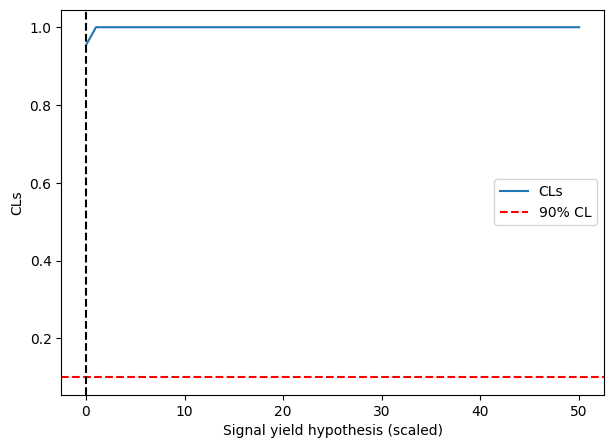

In [38]:
plt.figure(figsize=(7,5))

plt.plot(sig_range, cls_vals, label="CLs")

plt.axhline(0.1, color='red', linestyle='--', label="90% CL")
plt.axvline(N_sig_limit, color='black', linestyle='--')

plt.xlabel("Signal yield hypothesis (scaled)")
plt.ylabel("CLs")
plt.legend()

plt.savefig("D:/b_meson_analysis/plots/cls_scan.png", dpi=300)
plt.show()

In [39]:
# Convert back to real signal yield
N_sig_limit_real = N_sig_limit * scale_factor

N_B = 387e6
eps = 0.05

BF = N_sig_limit_real / (N_B * eps)

print(f"Real signal limit: N_sig < {N_sig_limit_real:.1f}")
print(f"BF upper limit: < {BF:.2e}")

Real signal limit: N_sig < 0.0
BF upper limit: < 0.00e+00


In [40]:
print("n_obs =", n_obs)
print("n_bkg =", n_bkg)

n_obs = 438079
n_bkg = 331623.4285714286
